In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
import torchvision.transforms as T
from sklearn.model_selection import train_test_split
import wandb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
!wget -q https://storage.googleapis.com/wandb_datasets/nature_12K.zip
!unzip -q nature_12K.zip
!ls

inaturalist_12K  nature_12K.zip  sample_data


In [ ]:
!find /content -name ".DS_Store" -delete

In [ ]:
from PIL import Image
from pathlib import Path

src = "/content/inaturalist_12K"
dst = "/content/inat_224"
img_size = 224

for split in ["train", "val"]:
    for cls in os.listdir(f"{src}/{split}"):
        cls_path = f"{src}/{split}/{cls}"
        if not os.path.isdir(cls_path):
            continue
        out_dir = Path(f"{dst}/{split}/{cls}")
        if out_dir.exists() and len(os.listdir(out_dir)) >= len(os.listdir(cls_path)):
            print("skip (done):", split, cls)
            continue
        out_dir.mkdir(parents=True, exist_ok=True)
        for fname in os.listdir(cls_path):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            try:
                im = Image.open(f"{cls_path}/{fname}").convert("RGB").resize((img_size, img_size))
                im.save(out_dir / fname)
            except Exception as e:
                print("skipped", fname, e)

In [ ]:
train_path = "/content/inat_224/train"
test_path  = "/content/inat_224/val"
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

eval_tf = T.Compose([T.ToTensor(), T.Normalize(mean, std)])

base_train = datasets.ImageFolder(train_path)
targets = base_train.targets
train_idx, val_idx = train_test_split(
    np.arange(len(targets)), test_size=0.2,
    stratify=targets, random_state=42,
)

test_set = datasets.ImageFolder(test_path, transform=eval_tf)
print(len(base_train.classes), base_train.classes)

FileNotFoundError: [Errno 2] No such file or directory: '/content/inat_224/train'

In [ ]:
import torchvision.models as models

def build_model(freeze_strategy="feature_extract", freeze_up_to=6, n_classes=10):
    """Load ImageNet-pretrained ResNet50, adapt to n_classes with a freezing strategy."""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    if freeze_strategy == "feature_extract":
        for p in model.parameters():
            p.requires_grad = False
    elif freeze_strategy == "freeze_up_to":
        children = list(model.children())
        for layer in children[:freeze_up_to]:
            for p in layer.parameters():
                p.requires_grad = False
    elif freeze_strategy == "full_finetune":
        pass

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, n_classes)
    return model

In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss_sum += criterion(logits, y).item() * y.size(0)
        correct  += (logits.argmax(1) == y).sum().item()
        total    += y.size(0)
    return loss_sum / total, correct / total

In [ ]:
def training_loop(freeze_strategy="feature_extract", freeze_up_to=6,
                  augment=False, batch_size=32, lr=1e-4,
                  epochs=10, optimizer_name="adam"):

    ops = []
    if augment:
        ops += [T.RandomHorizontalFlip(), T.RandomRotation(15),
                T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)]
    ops += [T.ToTensor(), T.Normalize(mean, std)]
    train_tf = T.Compose(ops)

    train_full = datasets.ImageFolder(train_path, transform=train_tf)
    val_full   = datasets.ImageFolder(train_path, transform=eval_tf)
    train_loader = DataLoader(Subset(train_full, train_idx), batch_size=batch_size,
                              shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(Subset(val_full, val_idx), batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)

    model = build_model(freeze_strategy=freeze_strategy, freeze_up_to=freeze_up_to).to(device)
    criterion = nn.CrossEntropyLoss()
    trainable = filter(lambda p: p.requires_grad, model.parameters())
    opt_map = {
        "adam":  lambda p: torch.optim.Adam(p, lr=lr),
        "adamw": lambda p: torch.optim.AdamW(p, lr=lr),
        "sgd":   lambda p: torch.optim.SGD(p, lr=lr, momentum=0.9),
    }
    optimizer = opt_map[optimizer_name](trainable)

    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
        val_loss, val_acc = evaluate(model, val_loader)
        wandb.log({"epoch": epoch, "val_loss": val_loss, "val_acc": val_acc})

    result = model
    del optimizer
    torch.cuda.empty_cache()
    return result

In [ ]:
sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_acc", "goal": "maximize"},
    "early_terminate": {"type": "hyperband", "min_iter": 3},
    "parameters": {
        "freeze_strategy": {"values": ["feature_extract", "freeze_up_to", "full_finetune"]},
        "freeze_up_to":    {"values": [5, 6, 7]},
        "lr":              {"distribution": "log_uniform_values", "min": 1e-5, "max": 1e-3},
        "batch_size":      {"values": [32, 64]},
        "augment":         {"values": [True, False]},
        "optimizer_name":  {"values": ["adam", "adamw"]},
        "epochs":          {"value": 10},
    },
}

In [ ]:
def sweep_run():
    wandb.init()
    cfg = dict(wandb.config)
    wandb.run.name = (f"{cfg['freeze_strategy']}_lr{cfg['lr']:.0e}"
                      f"_bs{cfg['batch_size']}_aug{int(cfg['augment'])}")
    training_loop(**cfg)

In [ ]:
'''
sweep_id = wandb.sweep(sweep_config, project="inaturalist-finetuned")
wandb.agent(sweep_id, sweep_run, count=15)
'''

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Create sweep with ID: ajdar8xx
Sweep URL: https://wandb.ai/parthd1901-bits-pilani/inaturalist-finetuned/sweeps/ajdar8xx


wandb: Agent Starting Run: d53ti92t with config:
wandb: 	augment: True
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	freeze_strategy: feature_extract
wandb: 	freeze_up_to: 5
wandb: 	lr: 0.00039387201375979417
wandb: 	optimizer_name: adamw
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: parthd1901 (parthd1901-bits-pilani) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 156MB/s]


...

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/wandb/agents/pyagent.py", line 314, in _run_job
    self._function()
  File "/tmp/ipykernel_457/1389164326.py", line 6, in sweep_run
    training_loop(**cfg)
  File "/tmp/ipykernel_457/2065496866.py", line 35, in training_loop
    x, y = x.to(device), y.to(device)
           ^^^^^^^^^^^^
Exception



epoch,▁▅█
val_acc,▁▅█
val_loss,█▄▁
epoch,2
val_acc,0.722
val_loss,1.1314


wandb: Agent Starting Run: nswsq407 with config:
wandb: 	augment: True
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	freeze_strategy: freeze_up_to
wandb: 	freeze_up_to: 5
wandb: 	lr: 3.769894693767693e-05
wandb: 	optimizer_name: adamw
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▂▃▃▄▅▆▆▇█
val_acc,▁▅▆▇▇▇█▇▇█
val_loss,█▂▁▁▁▂▂▄▃▅
epoch,9
val_acc,0.847
val_loss,0.60775


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: hirv1pt6 with config:
wandb: 	augment: False
wandb: 	batch_size: 64
wandb: 	epochs: 10
wandb: 	freeze_strategy: freeze_up_to
wandb: 	freeze_up_to: 5
wandb: 	lr: 2.5783992345532905e-05
wandb: 	optimizer_name: adamw
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


In [ ]:
best_config = {
    "freeze_strategy": "full_finetune",
    "freeze_up_to": 6,
    "lr": 2e-5,
    "batch_size": 64,
    "augment": True,
    "optimizer_name": "adamw",
    "epochs": 15,
}
wandb.init(project="inaturalist-finetuned", name="partB-best-final", config=best_config)
best_model_B = training_loop(**best_config)
wandb.finish()
torch.save(best_model_B.state_dict(), "best_model_partB.pt")

test_loader = DataLoader(test_set, batch_size=64, shuffle=False,
                         num_workers=2, pin_memory=True)
test_loss, test_acc = evaluate(best_model_B, test_loader)
print(f"Part B test accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: parthd1901 (parthd1901-bits-pilani) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 122MB/s]


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
val_acc,▁▅▇▇▇██▇███████
val_loss,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,14
val_acc,0.845
val_loss,0.55857


Part B test accuracy: 0.8450


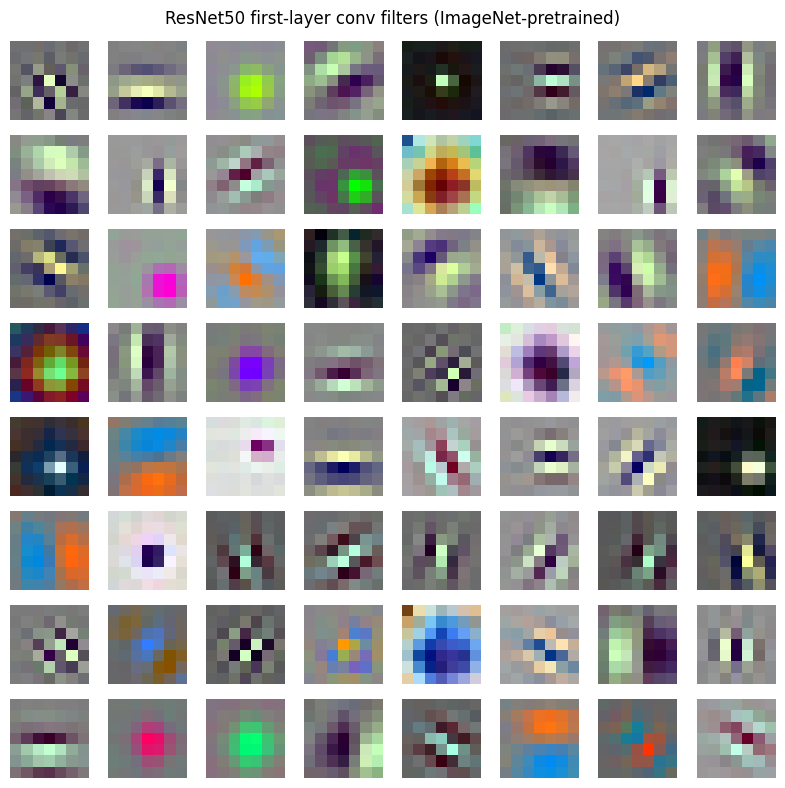

In [ ]:
best_model_B = build_model(freeze_strategy="full_finetune").to(device)
state = torch.load("best_finetuned_model.pt", map_location=device)
best_model_B.load_state_dict(state)
best_model_B.eval()

import matplotlib.pyplot as plt

conv1 = best_model_B.conv1
weights = conv1.weight.data.clone().cpu()
n_filters = weights.shape[0]

w = weights.clone()
w -= w.amin(dim=(1, 2, 3), keepdim=True)
w /= (w.amax(dim=(1, 2, 3), keepdim=True) + 1e-8)

cols = 8
rows = (n_filters + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
for i, ax in enumerate(axes.flatten()):
    if i < n_filters:
        ax.imshow(w[i].permute(1, 2, 0).numpy())
    ax.axis("off")
plt.suptitle("ResNet50 first-layer conv filters (ImageNet-pretrained)")
plt.tight_layout()
plt.savefig("resnet_first_layer_filters.png", dpi=120, bbox_inches="tight")
plt.show()